# 04 — Random Forest

**O que é:** ensemble de múltiplas árvores de decisão, onde cada árvore é treinada em uma amostra aleatória dos dados (bootstrap) e usa subconjunto aleatório de features. A previsão final é a votação majoritária das árvores.

**Vantagens:** robusto a outliers, captura não-linearidades, fornece importância das features.

**Desvantagens:** menos interpretável que regressão logística, mais lento.

## Pipeline de Dados (15 features + janelas deslizantes)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc

TARGET = 'Status_bin'
METRICAS = ['Pts', 'SG', 'Gols_Pro', 'Gols_Contra', 'V', 'Aproveitamento']
JANELAS  = [3, 5]
FEATURES_ELENCO = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
FEATURES_JANELA = [f'{m}_media_{w}' for m in METRICAS for w in JANELAS]
FEATURES = FEATURES_ELENCO + FEATURES_JANELA

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 1 if str(x).strip().lower() == 'rebaixado' else 0)
df_desemp = pd.read_excel(os.path.join('..', 'dados', 'tabela_desempenho_brasileirao.xlsx'), sheet_name='Todos')
df_desemp.columns = df_desemp.columns.str.strip()
df_desemp = df_desemp.sort_values(['Clube', 'Temporada']).reset_index(drop=True)
for m in METRICAS:
    for w in JANELAS:
        df_desemp[f'{m}_media_{w}'] = (
            df_desemp.groupby('Clube')[m]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )
COLS_MERGE = ['Clube', 'Temporada'] + FEATURES_JANELA
clubes_2025 = df['Clube'][df['Temporada'] == 2025].unique()
rows_2025 = []
for clube in clubes_2025:
    hist = df_desemp[df_desemp['Clube'] == clube].sort_values('Temporada', ascending=False)
    row  = {'Clube': clube, 'Temporada': 2025}
    for m in METRICAS:
        for w in JANELAS:
            ultimos = hist.head(w)[m]
            row[f'{m}_media_{w}'] = ultimos.mean() if len(ultimos) > 0 else None
    rows_2025.append(row)
df_ext = pd.concat([df_desemp[COLS_MERGE], pd.DataFrame(rows_2025)[COLS_MERGE]], ignore_index=True)
df = df.merge(df_ext[COLS_MERGE], on=['Clube', 'Temporada'], how='left')
df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022].copy()
df_te  = df_rot[df_rot['Temporada']  > 2022].copy()
mediana_treino = df_tr[FEATURES_JANELA].median()
for col in FEATURES_JANELA:
    df_tr[col] = df_tr[col].fillna(mediana_treino[col])
    df_te[col] = df_te[col].fillna(mediana_treino[col])
scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES]); y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES]);     y_te = df_te[TARGET].values
print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 15) | Teste: (40, 15)


## Walk-Forward Validation — Random Forest

In [2]:
# Walk-forward validation — Random Forest
temporadas_treino = sorted(df_tr['Temporada'].unique())
N_FOLDS = 5; inicio_val = len(temporadas_treino) - N_FOLDS
fold_results = []
for i in range(N_FOLDS):
    anos_tr = temporadas_treino[:inicio_val + i]
    ano_val = temporadas_treino[inicio_val + i]
    d_tr = df_rot[df_rot['Temporada'].isin(anos_tr)].copy()
    d_val= df_rot[df_rot['Temporada'] == ano_val].copy()
    med = d_tr[FEATURES_JANELA].median()
    for col in FEATURES_JANELA:
        d_tr[col] = d_tr[col].fillna(med[col])
        d_val[col]= d_val[col].fillna(med[col])
    sc = StandardScaler()
    Xf = sc.fit_transform(d_tr[FEATURES]); Xv = sc.transform(d_val[FEATURES])
    yf = d_tr[TARGET].values;              yv = d_val[TARGET].values
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    clf.fit(Xf, yf)
    prob_v = clf.predict_proba(Xv)[:, 1]
    acc_v  = accuracy_score(yv, clf.predict(Xv))
    auc_v  = roc_auc_score(yv, prob_v) if yv.sum() > 0 else float('nan')
    fold_results.append({'Fold': i+1, 'Treino': f'{anos_tr[0]}-{anos_tr[-1]}',
                         'Validacao': str(ano_val), 'Acuracia': round(acc_v,4), 'AUC-ROC': round(auc_v,4)})
    print(f'Fold {i+1} | treino {anos_tr[0]}-{anos_tr[-1]} | val {ano_val} | Acc={acc_v:.3f} | AUC={auc_v:.3f}')
df_folds_rf = pd.DataFrame(fold_results)
print(f'\nMedia AUC-ROC: {df_folds_rf["AUC-ROC"].mean():.3f} (+/- {df_folds_rf["AUC-ROC"].std():.3f})')
print(df_folds_rf.to_string(index=False))

Fold 1 | treino 2014-2017 | val 2018 | Acc=0.800 | AUC=0.789
Fold 2 | treino 2014-2018 | val 2019 | Acc=0.850 | AUC=0.734
Fold 3 | treino 2014-2019 | val 2020 | Acc=0.750 | AUC=0.758
Fold 4 | treino 2014-2020 | val 2021 | Acc=0.700 | AUC=0.656
Fold 5 | treino 2014-2021 | val 2022 | Acc=0.750 | AUC=0.875

Media AUC-ROC: 0.762 (+/- 0.080)
 Fold    Treino Validacao  Acuracia  AUC-ROC
    1 2014-2017      2018      0.80   0.7891
    2 2014-2018      2019      0.85   0.7344
    3 2014-2019      2020      0.75   0.7578
    4 2014-2020      2021      0.70   0.6562
    5 2014-2021      2022      0.75   0.8750


## Otimização de Hiperparâmetros (RandomizedSearchCV + TimeSeriesSplit)

In [3]:
tscv = TimeSeriesSplit(n_splits=5)
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth':    [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
search_rf = RandomizedSearchCV(base_rf, param_distributions=param_dist,
                                n_iter=50, scoring='roc_auc', cv=tscv,
                                random_state=42, n_jobs=1)
search_rf.fit(X_tr, y_tr)
print('Melhores parametros:', search_rf.best_params_)
print(f'Melhor AUC-ROC (CV): {search_rf.best_score_:.3f}')
rf = search_rf.best_estimator_

Melhores parametros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3}
Melhor AUC-ROC (CV): 0.757


## Avaliação no Conjunto de Teste (2023–2024)
Métrica principal: **AUC-ROC**

Acuracia: 0.800 | AUC-ROC: 0.844
              precision    recall  f1-score   support

   Permanece       0.85      0.91      0.88        32
   Rebaixado       0.50      0.38      0.43         8

    accuracy                           0.80        40
   macro avg       0.68      0.64      0.65        40
weighted avg       0.78      0.80      0.79        40



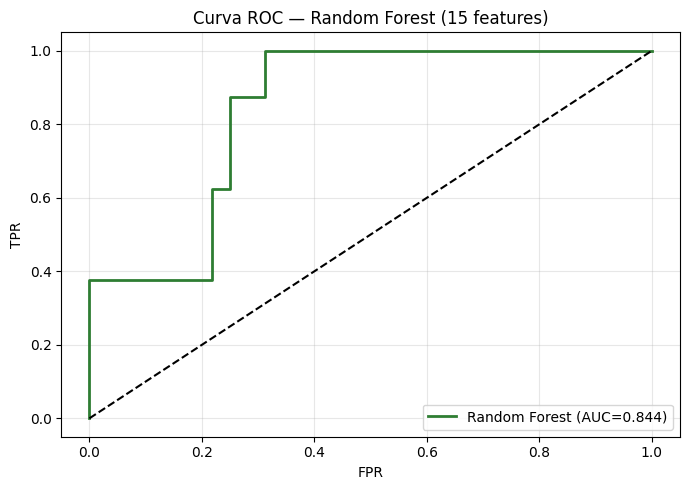

In [4]:
y_pred = rf.predict(X_te)
y_prob = rf.predict_proba(X_te)[:, 1]
acc    = accuracy_score(y_te, y_pred)
aucroc = roc_auc_score(y_te, y_prob)
print(f'Acuracia: {acc:.3f} | AUC-ROC: {aucroc:.3f}')
print(classification_report(y_te, y_pred, target_names=['Permanece', 'Rebaixado']))

fpr, tpr, _ = roc_curve(y_te, y_prob)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color='#2e7d32', lw=2, label=f'Random Forest (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curva ROC — Random Forest (15 features)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Importância das Features

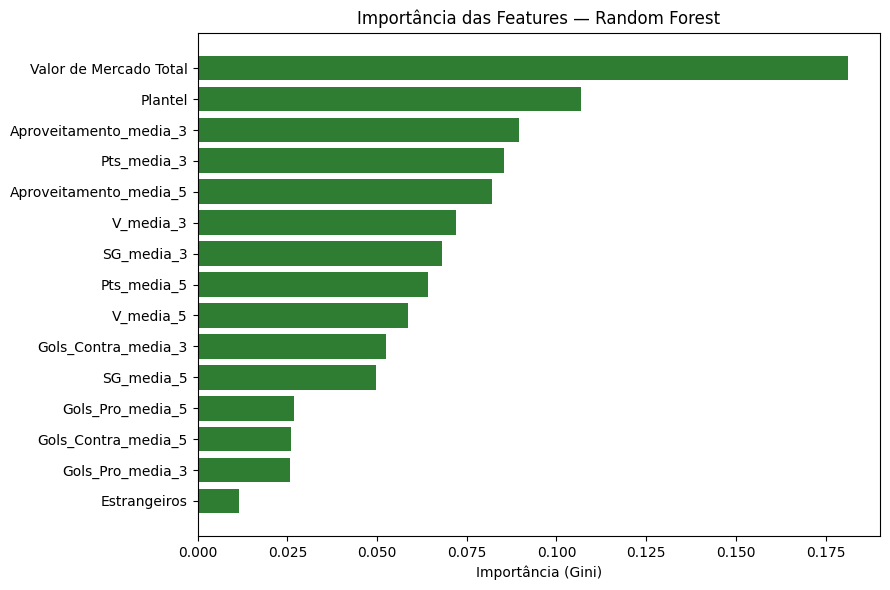

               Feature  Importancia
Valor de Mercado Total     0.181119
               Plantel     0.106915
Aproveitamento_media_3     0.089503
           Pts_media_3     0.085338
Aproveitamento_media_5     0.081995
             V_media_3     0.072012
            SG_media_3     0.068091
           Pts_media_5     0.064193
             V_media_5     0.058517
   Gols_Contra_media_3     0.052413
            SG_media_5     0.049788
      Gols_Pro_media_5     0.026816
   Gols_Contra_media_5     0.026097
      Gols_Pro_media_3     0.025627
          Estrangeiros     0.011577


In [5]:
imp = pd.DataFrame({'Feature': FEATURES, 'Importancia': rf.feature_importances_})
imp = imp.sort_values('Importancia', ascending=False)
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(imp['Feature'], imp['Importancia'], color='#2e7d32')
ax.set_xlabel('Importância (Gini)'); ax.set_title('Importância das Features — Random Forest')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
print(imp.to_string(index=False))

## Salvando o Modelo Otimizado

In [6]:
os.makedirs(os.path.join('..', 'modelos'), exist_ok=True)
joblib.dump(rf,     os.path.join('..', 'modelos', 'random_forest.pkl'))
joblib.dump(scaler, os.path.join('..', 'modelos', 'scaler_rf.pkl'))
print('Salvos: random_forest.pkl | scaler_rf.pkl')
print(f'AUC-ROC final: {aucroc:.3f}')

Salvos: random_forest.pkl | scaler_rf.pkl
AUC-ROC final: 0.844
